# Neuronale Netze

Dieses Notebook zeigt Schritt für Schritt, warum wir ein neuronales Netz (NN) brauchen und wie Forward- und Backpropagation funktionieren.

## Warum überhaupt ein neuronales Netz?
Ein lineares Modell (z.B. logistische Regression) trennt Klassen mit einer **Geraden** (in 2D) oder Hyper-Ebene (in höheren Dimensionen). Treffen die Klassen jedoch eine nichtlineare Struktur (Ring, Spirale), versagt ein rein lineares Ansatz. Ein neuronales Netz führt Zwischenschichten mit nichtlinearen Aktivierungen ein. Dadurch kann das Modell eine Transformation des Eingaberaums lernen, in dem die Klassen dann wieder linear separierbar sind.

## Überblick über die Schritte
1. Synthetische Daten erzeugen und speichern (CSV)
2. Daten einlesen und visualisieren
3. Lineares Baseline-Modell (logistische Regression) trainieren – zeigt Grenzen
4. Kleines Netzwerk (2 -> 4 -> 1) definieren
5. Forward Pass (Linear + ReLU + Linear + Sigmoid)
6. Verlustfunktion (Log-Loss / Kreuzentropie) und Herleitung der Gradienten
7. Training über viele Epochen, Aufzeichnung von Loss & Accuracy
8. Visualisierung: Loss-Kurve & Entscheidungsgrenze
9. Detaillierter Forward-Pass für einen Beispielpunkt
10. Vergleich: Feature Engineering (Radius) vs. NN

---

In [11]:
import csv
import math
import random

'''
x1, x2: Eingabefeatures. 2D‑Koordinaten eines Punkts; bilden den Featurevektor [x1, x2] für das lineare Modell und das NN (Forward‑Pass, Entscheidungsfläche, Visualisierung).

label: Zielvariable (y \in {0,1}). Aus der Datenerzeugung: 1, wenn der Radius (r > 0.5), sonst 0. Dient zum Berechnen des Kreuzentropie‑Loss, zum Gradientenupdate und zur Accuracy‑Bewertung.
'''

# 1. CSV erzeugen (zweidimensionale Punkte: Klasse 0 (Ring innen), Klasse 1 (Ring außen))
random.seed(42)
with open("data.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["x1", "x2", "label"])
    for _ in range(400):
        r = random.uniform(0, 1)
        angle = random.uniform(0, 2 * math.pi)
        x1 = r * math.cos(angle)
        x2 = r * math.sin(angle)
        label = 1 if r > 0.5 else 0
        writer.writerow([x1, x2, label])


## Daten laden
Wir lesen die erzeugte CSV und speichern Features (X) und Labels (y).

In [12]:
# 2. Daten laden
X = []
labels_list = []
with open("data.csv") as f:
    reader = csv.DictReader(f)
    for row in reader:
        X.append([float(row["x1"]), float(row["x2"])] )
        labels_list.append(float(row["label"]))


## Datenvisualisierung
Die Punkte im Koordinatensystem: innen (Radius <= 0.5) Klasse 0, außen Klasse 1.

Der Ring-Datensatz zeigt eine nichtlineare Klassenstruktur: Punkte werden zufällig im Kreis (Radius 0 bis 1) verteilt und nach Radius in zwei Klassen eingeteilt (<= 0.5 Klasse 0, > 0.5 Klasse 1). Er drückt aus, dass die wahre Entscheidungsgrenze kreisförmig ist und ein lineares Modell (Gerade) diese Struktur nicht angemessen trennen kann. Damit illustriert er den Bedarf für nichtlineare Transformationen (z. B. neuronales Netz oder manuelles Radius-Feature).

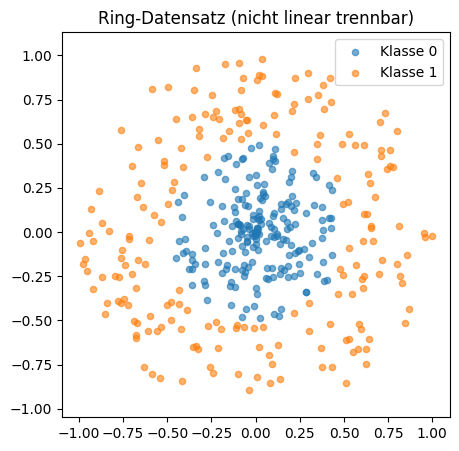

In [13]:
import matplotlib.pyplot as plt

xs0 = [p[0] for p, lbl in zip(X, labels_list) if lbl == 0]
ys0 = [p[1] for p, lbl in zip(X, labels_list) if lbl == 0]
xs1 = [p[0] for p, lbl in zip(X, labels_list) if lbl == 1]
ys1 = [p[1] for p, lbl in zip(X, labels_list) if lbl == 1]
plt.figure(figsize=(5,5))
plt.scatter(xs0, ys0, s=20, alpha=0.6, label="Klasse 0")
plt.scatter(xs1, ys1, s=20, alpha=0.6, label="Klasse 1")
plt.title("Ring-Datensatz (nicht linear trennbar)")
plt.legend()
plt.axis("equal")
plt.show()


## Lineares Baseline-Modell (Logistische Regression)
Wir trainieren ein Modell ohne versteckte Schicht: \( z = w_1 x_1 + w_2 x_2 + b \), Ausgabe \( \sigma(z) \). Dieses Modell kann nur lineare Trennung – wir erwarten relativ schlechte Accuracy.

[Linear] Epoch 250: Loss=0.6907 Acc=0.49
[Linear] Epoch 500: Loss=0.6906 Acc=0.49
[Linear] Epoch 750: Loss=0.6906 Acc=0.49
[Linear] Epoch 1000: Loss=0.6906 Acc=0.49


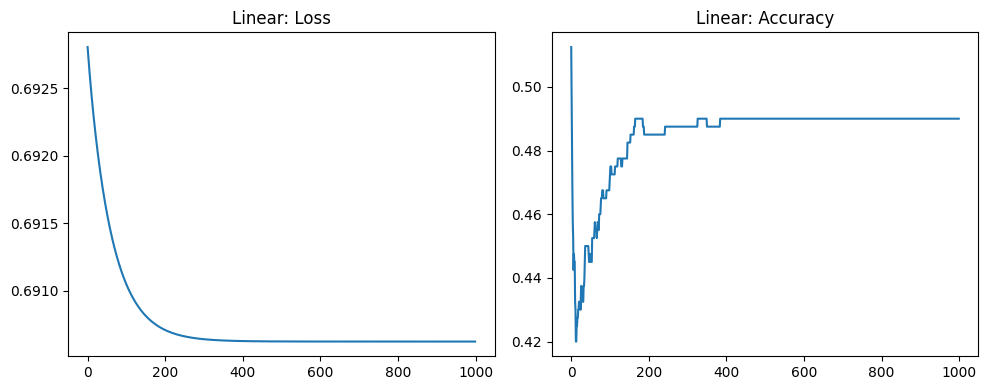

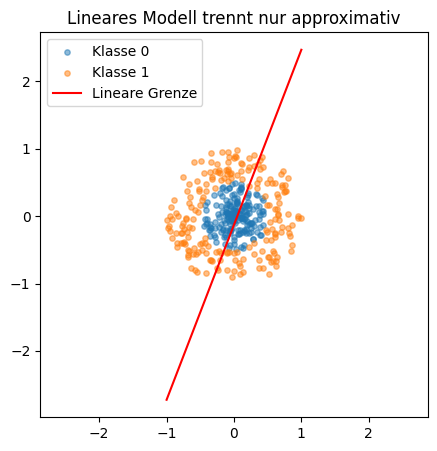

In [14]:
# Logistische Regression via einfacher Gradientabstieg
w = [random.uniform(-0.1,0.1), random.uniform(-0.1,0.1)]
b = 0.0
lr_lin = 0.2
epochs_lin = 1000
lin_loss_hist = []
lin_acc_hist = []
for ep in range(epochs_lin):
    grad_w = [0.0, 0.0]
    grad_b = 0.0
    loss_sum = 0.0
    correct = 0
    for i, (x1,x2) in enumerate(X):
        z = w[0]*x1 + w[1]*x2 + b
        p = 1/(1+math.exp(-z))
        label_value = labels_list[i]  # renamed y_true
        loss = -(label_value*math.log(p+1e-9) + (1-label_value)*math.log(1-p+1e-9))
        loss_sum += loss
        # Gradienten: dL/dz = p - y
        dz = p - label_value
        grad_w[0] += dz * x1
        grad_w[1] += dz * x2
        grad_b += dz
        pred = 1 if p>=0.5 else 0
        if pred == label_value:
            correct += 1
    n = len(X)
    w[0] -= lr_lin * grad_w[0] / n
    w[1] -= lr_lin * grad_w[1] / n
    b -= lr_lin * grad_b / n
    lin_loss_hist.append(loss_sum/n)
    lin_acc_hist.append(correct/n)
    if (ep+1) % 250 == 0:
        print(f"[Linear] Epoch {ep+1}: Loss={loss_sum/n:.4f} Acc={correct/n:.2f}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(lin_loss_hist)
plt.title("Linear: Loss")
plt.subplot(1,2,2)
plt.plot(lin_acc_hist)
plt.title("Linear: Accuracy")
plt.tight_layout()
plt.show()

# Entscheidungsgrenze des linearen Modells
import numpy as np
xx = np.linspace(-1,1,200)
yy = -(w[0]*xx + b)/ (w[1] + 1e-9)
plt.figure(figsize=(5,5))
plt.scatter(xs0, ys0, s=15, alpha=0.5, label="Klasse 0")
plt.scatter(xs1, ys1, s=15, alpha=0.5, label="Klasse 1")
plt.plot(xx, yy, 'r', label='Lineare Grenze')
plt.title("Lineares Modell trennt nur approximativ")
plt.axis('equal')
plt.legend()
plt.show()


## Warum das lineare Modell scheitert
Die echte Grenze ist ein Kreis. Eine Gerade kann diesen Kreis nur begrenzt approximieren – wir verlieren Genauigkeit. Ein NN bildet durch seine versteckte Schicht eine Funktion \( h(x) = \text{ReLU}(W_1 x + b_1) \) die Merkmale neu kombiniert, bevor eine finale lineare Trennung erfolgt.

## Aktivierungsfunktionen
ReLU führt Nichtlinearität ein. Sigmoid am Ende wandelt den Wert in eine Wahrscheinlichkeit um.

In [15]:
# 3. Hilfsfunktionen
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

def relu(z):
    return z if z > 0 else 0

def relu_deriv(z):
    return 1 if z > 0 else 0


## Netzwerk-Initialisierung
Wir initialisieren Gewichte mit kleinen Zufallswerten. Architektur: 2 Eingänge -> 4 Neuronen versteckte Schicht -> 1 Ausgang.

In [16]:
# 4. Netzwerk-Parameter (2 -> 4 -> 1)
import random
def rand():
    return random.uniform(-0.5, 0.5)

W1 = [[rand(), rand(), rand(), rand()],
      [rand(), rand(), rand(), rand()]]  # Shape (2,4)
b1 = [0.0, 0.0, 0.0, 0.0]

W2 = [rand(), rand(), rand(), rand()]    # Shape (4,)
b2 = 0.0

lr = 0.05
epochs = 3000

loss_history = []
acc_history = []


## Herleitung der Gradienten (kurz)
Für den Output: \( a_2 = \sigma(z_2) \), \( z_2 = \sum_j a_{1,j} W_{2,j} + b_2 \).
Log-Loss pro Sample: \( L = -[y \log a_2 + (1-y)\log(1-a_2)] \).
Ableitung: \( \partial L/ \partial z_2 = a_2 - y \).
Hidden-Neuron j: \( z_{1,j} = W_{1,0,j} x_0 + W_{1,1,j} x_1 + b_{1,j} \), \( a_{1,j} = \text{ReLU}(z_{1,j}) \). ReLU-Ableitung: 1 falls \( z_{1,j} > 0 \), sonst 0.
Gradientenfluss: \( \partial L/\partial a_{1,j} = (a_2 - y) W_{2,j} \) und \( \partial L/\partial z_{1,j} = \partial L/\partial a_{1,j} * \text{ReLU}'(z_{1,j}) \).

## Training (Forward + Backprop + Update)
Wir akkumulieren Gradienten über alle Samples (Batch Gradient Descent) und aktualisieren danach Gewichte und Bias.

In [17]:
for epoch in range(epochs):
    loss_sum = 0.0
    correct = 0
    # Gradients akkumulieren
    dW1 = [[0.0]*4 for _ in range(2)]
    db1 = [0.0]*4
    dW2 = [0.0]*4
    db2_acc = 0.0

    for i, x in enumerate(X):
        # Forward
        z1 = [x[0]*W1[0][j] + x[1]*W1[1][j] + b1[j] for j in range(4)]
        a1 = [relu(z) for z in z1]
        z2 = sum(a1[j]*W2[j] for j in range(4)) + b2
        a2 = sigmoid(z2)

        # Verlust (log loss)
        label_value = labels_list[i]
        loss = -(label_value*math.log(a2 + 1e-9) + (1 - label_value)*math.log(1 - a2 + 1e-9))
        loss_sum += loss
        pred = 1 if a2 >= 0.5 else 0
        if pred == label_value:
            correct += 1

        # Backprop Ausgang -> W2, b2
        dz2 = a2 - label_value                 # dL/dz2
        for j in range(4):
            dW2[j] += dz2 * a1[j]
        db2_acc += dz2

        # Backprop versteckte Schicht
        for j in range(4):
            da1 = dz2 * W2[j]
            dz1 = da1 * relu_deriv(z1[j])
            dW1[0][j] += dz1 * x[0]
            dW1[1][j] += dz1 * x[1]
            db1[j] += dz1

    # Parameter-Update (mittlere Gradienten)
    n = len(X)
    for j in range(4):
        W2[j] -= lr * (dW2[j] / n)
    b2 -= lr * (db2_acc / n)
    for j in range(4):
        W1[0][j] -= lr * (dW1[0][j] / n)
        W1[1][j] -= lr * (dW1[1][j] / n)
        b1[j] -= lr * (db1[j] / n)

    avg_loss = loss_sum / n
    accuracy = correct / n
    loss_history.append(avg_loss)
    acc_history.append(accuracy)
    if (epoch + 1) % 500 == 0:
        print(f"[NN] Epoch {epoch+1}: Loss={avg_loss:.4f} Accuracy={accuracy:.2f}")


[NN] Epoch 500: Loss=0.6602 Accuracy=0.74
[NN] Epoch 1000: Loss=0.5796 Accuracy=0.80
[NN] Epoch 1500: Loss=0.4893 Accuracy=0.80
[NN] Epoch 2000: Loss=0.4390 Accuracy=0.81
[NN] Epoch 2500: Loss=0.4037 Accuracy=0.83
[NN] Epoch 3000: Loss=0.3393 Accuracy=0.86


## Vergleich Lernverlauf (NN)
Das NN sollte höhere Accuracy erreichen als das lineare Modell.

NN Loss: Mittlerer Kreuzentropie‑Verlust (Log‑Loss) des neuronalen Netzes pro Epoche, über alle Trainingspunkte gemittelt. Misst, wie gut die vorhergesagten Wahrscheinlichkeiten zu den Labels passen. Kleiner ist besser; stark empfindlich gegenüber über-sicheren Fehlvorhersagen.

NN Accuracy: Anteil korrekt klassifizierter Punkte pro Epoche mit Schwelle p≥0.5. Werte zwischen 0 und 1. Leicht interpretierbar, aber weniger aussagekräftig über die Kalibrierung der Wahrscheinlichkeiten.
Accuracy Vergleich: Gegenüberstellung der Genauigkeitskurven des linearen Baseline‑Modells (lin_acc_hist) und des NN (acc_history) über die Epochen. Zeigt direkt, dass das NN auf der nichtlinearen Ringstruktur typischerweise eine höhere Genauigkeit erreicht als das lineare Modell.

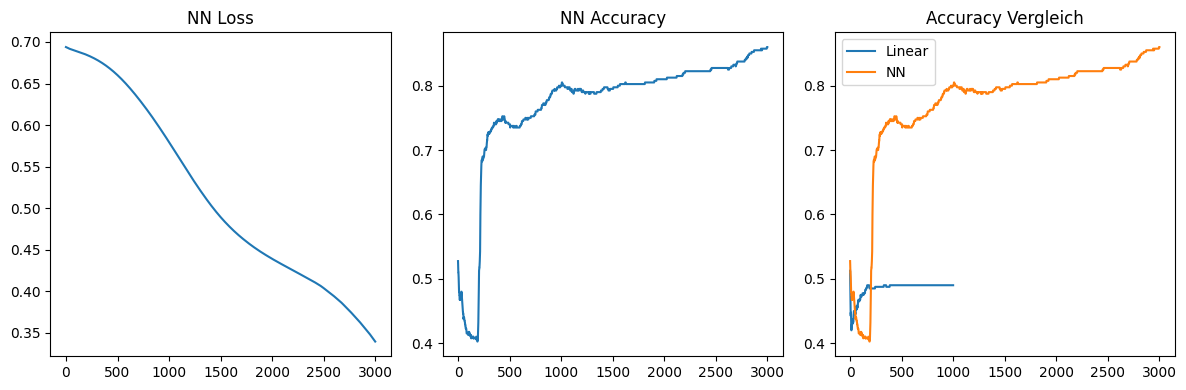

In [18]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(loss_history)
plt.title("NN Loss")
plt.subplot(1,3,2)
plt.plot(acc_history)
plt.title("NN Accuracy")
plt.subplot(1,3,3)
plt.plot(lin_acc_hist, label='Linear')
plt.plot(acc_history, label='NN')
plt.title("Accuracy Vergleich")
plt.legend()
plt.tight_layout()
plt.show()


## Entscheidungsgrenze (NN)
Grid mit vorhergesagter Wahrscheinlichkeit.

Die NN‑Entscheidungsfläche ist die von dem Netzwerk gelernte Abbildung vom Eingaberaum auf die vorhergesagte Wahrscheinlichkeit p(y=1|x). In 2D wird sie als Farbfläche/Isolinien dargestellt.

Bedeutung: Für jeden Punkt x zeigt die Farbe p(y=1|x). Die Linie p=0.5 ist die Entscheidungsgrenze (Wechsel der Klasse).

Ausdruck: Welche Bereiche des Eingaberaums das Modell als Klasse 0 bzw. 1 einstuft und wie sicher es dabei ist (Farbsättigung => Konfidenz).

Nichtlinearität: Form und Krümmung zeigen, welche nichtlineare Trennung das NN gelernt hat.
Im Ring‑Datensatz: Die Fläche bildet eine annähernd kreisförmige Grenze ab, passend zur wahren Struktur, im Gegensatz zur Geraden der logistischen Regression.

Diagnose: Sehr zerklüftete Flächen deuten auf Overfitting, zu glatte und unpassende Formen auf Underfitting.

Schwelle: Ändert man den Schwellenwert (statt 0.5), verschiebt sich die Grenze entsprechend.

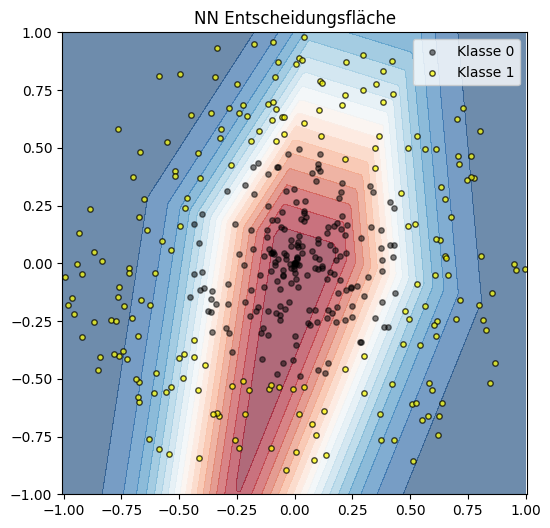

In [19]:
# Funktion für Vorhersage eines Punkts
def predict_proba(point):
    z1 = [point[0]*W1[0][j] + point[1]*W1[1][j] + b1[j] for j in range(4)]
    a1 = [relu(z) for z in z1]
    z2 = sum(a1[j]*W2[j] for j in range(4)) + b2
    return sigmoid(z2)

grid_x = np.linspace(-1,1,150)
grid_y = np.linspace(-1,1,150)
Z = np.zeros((len(grid_x), len(grid_y)))
for i, gx in enumerate(grid_x):
    for j, gy in enumerate(grid_y):
        Z[i,j] = predict_proba([gx, gy])

plt.figure(figsize=(6,6))
plt.contourf(grid_x, grid_y, Z.T, levels=20, cmap="RdBu", alpha=0.6)
plt.scatter(xs0, ys0, s=15, c="black", alpha=0.5, label="Klasse 0")
plt.scatter(xs1, ys1, s=15, c="yellow", edgecolors="black", alpha=0.7, label="Klasse 1")
plt.title("NN Entscheidungsfläche")
plt.axis("equal")
plt.legend()
plt.show()


## Schritt-für-Schritt Forward-Pass
Wir schauen uns für einen Beispielpunkt alle Zwischenwerte an, um die Mechanik zu verstehen.

ReLU „schaltet“ zwei Neuronen ab (negatives z1), zwei liefern positive Beiträge. Die Summe mit den Ausgangsgewichten ergibt ein negatives z2, dessen Sigmoid‑Wert unter 0.5 liegt, daher Vorhersage Klasse 0. Die exakten Zahlen hängen von den aktuell gelernten Gewichten und Biases ab.

In [20]:
# Beispielpunkt Forward-Pass detailliert
example = [0.3, 0.3]
# Berechne alle Zwischenschritte
z1_vals = [example[0]*W1[0][j] + example[1]*W1[1][j] + b1[j] for j in range(4)]
a1_vals = [relu(z) for z in z1_vals]
z2_val = sum(a1_vals[j]*W2[j] for j in range(4)) + b2
# Ausgabe
a2_val = sigmoid(z2_val)
print("Beispielpunkt:", example)
for j, (zv, av) in enumerate(zip(z1_vals, a1_vals)):
    print(f" Hidden Neuron {j}: z1={zv:.4f}, a1=ReLU(z1)={av:.4f}")
print(f" Output Linear z2={z2_val:.4f}")
print(f" Sigmoid(ausgabe)={a2_val:.4f} => Klasse {(1 if a2_val>=0.5 else 0)}")


Beispielpunkt: [0.3, 0.3]
 Hidden Neuron 0: z1=0.5452, a1=ReLU(z1)=0.5452
 Hidden Neuron 1: z1=0.0944, a1=ReLU(z1)=0.0944
 Hidden Neuron 2: z1=-0.0204, a1=ReLU(z1)=0.0000
 Hidden Neuron 3: z1=-0.9672, a1=ReLU(z1)=0.0000
 Output Linear z2=-0.6328
 Sigmoid(ausgabe)=0.3469 => Klasse 0


## Intuitive Analogie
Ein NN ist wie ein Team von Spezialisten: Jede versteckte Neuronen-Gruppe (Schicht) extrahiert eine andere Sicht (Feature) aus den Rohdaten. Beim Ring-Datensatz muss das Modell effektiv den Radius erkennen. Das einzelne lineare Modell sieht nur x und y separat – das NN kombiniert sie durch seine Gewichte so, dass ein "Radius-ähnliches" internes Feature entsteht.

## Manuelles Feature Engineering vs. Lernen
Wenn wir den Radius \( r = \sqrt{x_1^2 + x_2^2} \) explizit hinzufügen, kann schon eine logistische Regression die Klassen besser trennen. Ein NN lernt solche Transformationen selbst – das erspart manuelles Feature Engineering bei komplexen Daten (Bilder, Text, Audio).

[Linear+Radius] Epoch 200: Acc=0.96 Loss=0.0000
[Linear+Radius] Epoch 400: Acc=0.98 Loss=0.0000
[Linear+Radius] Epoch 600: Acc=0.99 Loss=0.0000


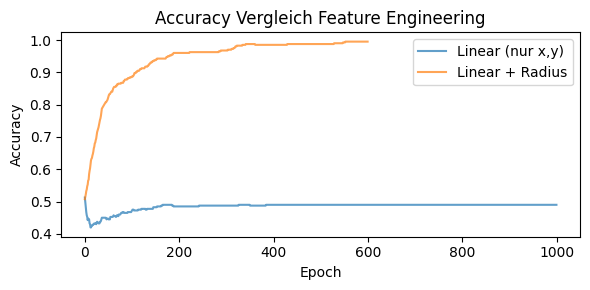

In [21]:
import math
# erweitertes lineares Modell mit zusätzlichem Radius-Feature
ext_w = [random.uniform(-0.1,0.1) for _ in range(3)]  # Gewichte für x1,x2,r
ext_b = 0.0
lr_ext = 0.2
epochs_ext = 600
ext_acc_hist = []
for ep in range(epochs_ext):
    grad_w = [0.0,0.0,0.0]
    grad_b = 0.0
    correct = 0
    loss_sum = 0.0
    for i,(x1,x2) in enumerate(X):
        r_feat = math.sqrt(x1*x1 + x2*x2)
        z = ext_w[0]*x1 + ext_w[1]*x2 + ext_w[2]*r_feat + ext_b
        p = 1/(1+math.exp(-z))
        label_value = labels_list[i]
        loss = -(label_value*math.log(p+1e-9) + (1-label_value)*math.log(1-p+1e-9))
        dz = p - label_value
        grad_w[0] += dz * x1
        grad_w[1] += dz * x2
        grad_w[2] += dz * r_feat
        grad_b += dz
        pred = 1 if p>=0.5 else 0
        if pred == label_value:
            correct += 1
    n = len(X)
    for j in range(3):
        ext_w[j] -= lr_ext * grad_w[j] / n
    ext_b -= lr_ext * grad_b / n
    ext_acc_hist.append(correct/n)
    if (ep+1) % 200 == 0:
        print(f"[Linear+Radius] Epoch {ep+1}: Acc={correct/n:.2f} Loss={loss_sum/n:.4f}")

plt.figure(figsize=(6,3))
plt.plot(lin_acc_hist, label='Linear (nur x,y)', alpha=0.7)
plt.plot(ext_acc_hist, label='Linear + Radius', alpha=0.7)
plt.title('Accuracy Vergleich Feature Engineering')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


## Hidden-Neuron-Aktivierungen analysieren
Wir betrachten die Aktivierungen der versteckten Schicht nach dem Training: Mindestens ein Neuron reagiert typischerweise auf den Radius oder bestimmte Bereiche.

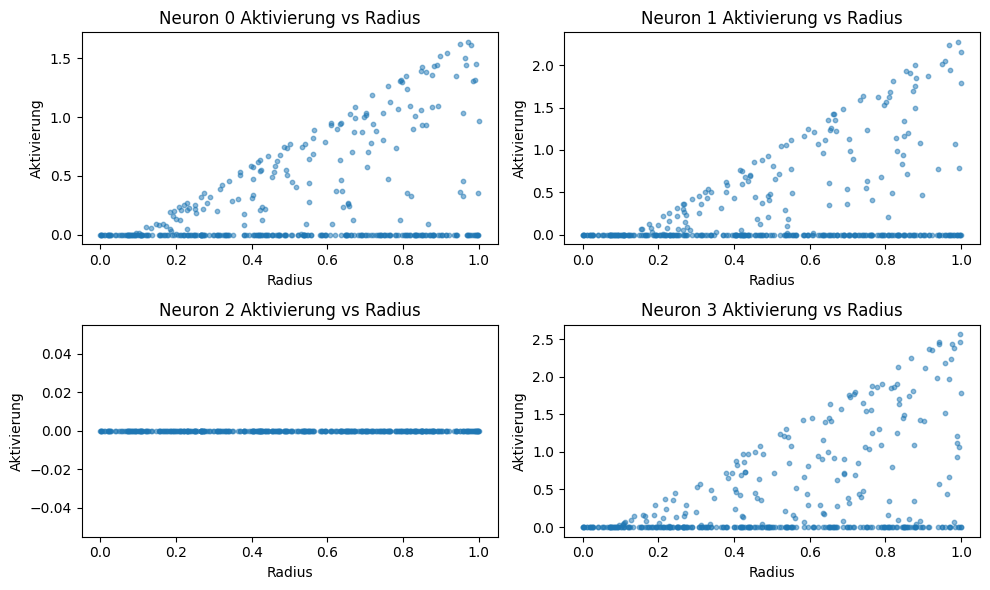

In [22]:
# Berechne Hidden-Aktivierungen für alle Punkte
hidden_acts = [[] for _ in range(4)]
for x1,x2 in X:
    z_vals = [x1*W1[0][j] + x2*W1[1][j] + b1[j] for j in range(4)]
    a_vals = [relu(z) for z in z_vals]
    for j in range(4):
        hidden_acts[j].append(a_vals[j])

radii = [math.sqrt(x1*x1 + x2*x2) for x1,x2 in X]
plt.figure(figsize=(10,6))
for j in range(4):
    plt.subplot(2,2,j+1)
    plt.scatter(radii, hidden_acts[j], s=10, alpha=0.5)
    plt.title(f'Neuron {j} Aktivierung vs Radius')
    plt.xlabel('Radius')
    plt.ylabel('Aktivierung')
plt.tight_layout()
plt.show()


## Fazit (erweitert)
Das NN ersetzt manuelles Feature Engineering (hier: Radius) durch gelerntes internes Repräsentationslernen. Wo wir beim einfachen Modell ein zusätzliches Merkmal basteln mussten, extrahiert das Netz implizit ähnliche Informationen.

- Zweck: Komplexe, nichtlineare Zusammenhänge modellieren.
- Funktionsweise: Verkettung linearer Transformationen + Nichtlinearitäten erzeugt flexible Funktionenräume.
- Vorteil: Automatische Merkmalserzeugung statt händischem Design.

Nächste Schritte:
- Mehr Schichten / andere Aktivierungen (Tanh, LeakyReLU)
- Regularisierung (L2, Dropout)
- Nutzung von PyTorch / TensorFlow für komplexere Modelle.
